# 02 — Feature Engineering
**Project:** Predicting Medication Non-Adherence in NCD Patients Using Classical Machine Learning  
**Dataset:** Kanyongo et al. (2024); Cimas Medical Aid Society, Zimbabwe ([Mendeley Data](https://data.mendeley.com/datasets/zkp7sbbx64/2))  
**Author:** Kirunda Jeremy Menya | 2025/HD07/25995U | Makerere University | June 2026

---

This notebook covers:
1. Environment setup, SSH, and repo clone
2. Load `cleaned.pkl` from Notebook 01
3. Engineer new features from existing columns
4. Encode and prepare all features for modelling
5. Define Feature Groups A, B, and C
6. Validate the engineered features (distributions, correlations with adherence)
7. Stratified train / validation / test split (70 / 15 / 15)
8. Save `features_A.pkl`, `features_B.pkl`, `features_C.pkl`, and `splits.pkl`
9. Push to GitHub

**Inputs:** `data/processed/cleaned.pkl`  
**Outputs:** `data/processed/features_A.pkl`, `features_B.pkl`, `features_C.pkl`, `data/processed/splits.pkl`


---
## 0. Environment Setup

The same libraries used in Notebook 01 are sufficient here. No additional installations are needed. Imports and helpers are redefined so that this notebook can be run independently without requiring Notebook 01 to be open.


In [59]:
import os, warnings, pickle
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "figure.dpi":        150,
})

PALETTE = {
    "adherent":     "#2196F3",
    "non_adherent": "#F44336",
    "neutral":      "#78909C",
    "highlight":    "#FF9800",
    "dark_grey":    "#455A64",
    "group_a":      "#9C27B0",
    "group_b":      "#00897B",
    "group_c":      "#1565C0",
}

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

FIGURES = "figures"
os.makedirs(f"{FIGURES}/feature_eng", exist_ok=True)

def save_figure(fig, filename, subfolder="feature_eng"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

def section(title):
    bar = "─" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

print("Imports ready.")


Imports ready.


---
## 0.1 SSH Key Upload and Repository Clone

The repository is cloned fresh into the Colab runtime at the start of each session. The SSH deploy key authenticates the clone and allows the notebook to push its outputs back to GitHub at the end.


In [60]:
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()   # select DMHTN_MedicationAdherence_deploy_key (NOT .pub)

!mv DMHTN_MedicationAdherence_deploy_key /root/.ssh/DMHTN_MedicationAdherence_deploy_key
!chmod 600 /root/.ssh/DMHTN_MedicationAdherence_deploy_key

ssh_config = """
Host github-dmhtn-medication-adherence
    HostName github.com
    User git
    IdentityFile /root/.ssh/DMHTN_MedicationAdherence_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'diabetes-hypertension-medication-adherence'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-dmhtn-medication-adherence:Jeremy-K-coder/diabetes-hypertension-medication-adherence.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')


Saving DMHTN_MedicationAdherence_deploy_key to DMHTN_MedicationAdherence_deploy_key
/content/diabetes-hypertension-medication-adherence
Already up to date.
Repo ready.


In [61]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
REPO_DIR   = f'/content/{REPO_NAME}'
DRIVE_BASE = '/content/drive/MyDrive/diabetes-hypertension-medication-adherence'
DATA_PROC  = os.path.join(REPO_DIR, 'data', 'processed')

os.makedirs(DATA_PROC, exist_ok=True)

FIGURES = os.path.join(REPO_DIR, 'figures')
os.makedirs(f"{FIGURES}/feature_eng", exist_ok=True)

def save_figure(fig, filename, subfolder="feature_eng"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

print(f"REPO_DIR  : {REPO_DIR}")
print(f"DATA_PROC : {DATA_PROC}")
print(f"FIGURES   : {FIGURES}")


REPO_DIR  : /content/diabetes-hypertension-medication-adherence
DATA_PROC : /content/diabetes-hypertension-medication-adherence/data/processed
FIGURES   : /content/diabetes-hypertension-medication-adherence/figures


---
## 1. Load the Cleaned Dataset

`cleaned.pkl` was saved at the end of Notebook 01 after all cleaning steps (column standardisation, label encoding, duplicate removal, dtype correction) were applied. Loading it here rather than re-running the cleaning code ensures both notebooks operate on exactly the same data.


In [63]:
section("1. Load cleaned.pkl")

cleaned_path = "/content/drive/MyDrive/diabetes-hypertension-medication-adherence/data/processed/cleaned.pkl"

with open(cleaned_path, "rb") as f:
    df = pickle.load(f)

TARGET = "adherence"

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target : {TARGET!r}  |  class balance: {df[TARGET].mean()*100:.1f}% adherent")
print()
print("Columns available:")
for c in df.columns:
    print(f"  {c}  ({df[c].dtype})")



──────────────────────────────────────────────────────────────────────
  1. Load cleaned.pkl
──────────────────────────────────────────────────────────────────────
Loaded: 24,071 rows x 12 columns
Target : 'adherence'  |  class balance: 40.2% adherent

Columns available:
  adherence  (int64)
  age  (int64)
  annualcontribution  (float64)
  annualclaimamount  (float64)
  unitstotal  (float64)
  gender_m  (bool)
  schemetype_medium  (bool)
  schemetype_premium  (bool)
  diagnosis_hypertension  (bool)
  covertype_standard  (bool)
  comorbidity_no_comorbidity  (bool)
  complicationdevelopment_no_complication  (bool)


---
## 2. Feature Engineering

The final dataset from Kanyongo et al. (2024) contains aggregated patient-level features but several clinically meaningful signals can still be derived from the existing columns. This section constructs those derived features one at a time, with each step motivated by clinical or analytical reasoning.

The features derivable from the final dataset are: `cost_burden_ratio`, `insurance_tier`, `age_group`, `is_comorbid`, `complication_flag`, and integer-encoded versions of the boolean columns. These are computed below.


### 2.1 Cost Burden Ratio

`cost_burden_ratio` is defined as `annualclaimamount / annualcontribution`: the proportion of a patient's annual insurance contribution that was consumed by their medication claims. A high ratio means the patient's claims approached or exceeded their premium, which is a proxy for financial stress. Patients under greater financial pressure from medication costs are more likely to skip refills.

The column is clipped at the 99th percentile to prevent a small number of extreme outliers (arising from very low contribution values or very high claim years) from dominating the feature space. Infinity values (which would occur if contribution were exactly zero) are not present in this dataset, but the clip is applied defensively.


In [64]:
section("2.1 Cost burden ratio")

df["cost_burden_ratio"] = df["annualclaimamount"] / df["annualcontribution"]

n_inf = np.isinf(df["cost_burden_ratio"]).sum()
print(f"Inf values: {n_inf}")

cap = df["cost_burden_ratio"].quantile(0.99)
df["cost_burden_ratio"] = df["cost_burden_ratio"].clip(upper=cap)

print(f"cost_burden_ratio; min: {df['cost_burden_ratio'].min():.6f}, "
      f"median: {df['cost_burden_ratio'].median():.6f}, "
      f"99th pct cap: {cap:.6f}, "
      f"max (after clip): {df['cost_burden_ratio'].max():.6f}")



──────────────────────────────────────────────────────────────────────
  2.1 Cost burden ratio
──────────────────────────────────────────────────────────────────────
Inf values: 0
cost_burden_ratio; min: 0.000000, median: 0.007530, 99th pct cap: 0.298843, max (after clip): 0.298843


### 2.2 Insurance Tier (Ordinal)

The dataset contains two boolean columns (`schemetype_medium` and `schemetype_premium`) that encode the patient's insurance plan. Patients where both flags are False are on the Basic plan. These three categories (Basic, Medium, Premium) represent an ordered hierarchy of coverage and premium cost, making ordinal encoding appropriate: Basic = 0, Medium = 1, Premium = 2.

This ordinal encoding preserves the natural ordering (a Premium member has more coverage than a Medium member, who in turn has more than a Basic member) without introducing the false assumption of equal spacing between categories that a simple integer encoding implies.


In [65]:
section("2.2 Insurance tier ordinal encoding")

df["insurance_tier"] = (
    df["schemetype_premium"].astype(int) * 2
    + df["schemetype_medium"].astype(int)
)

# Verify: no patient should have both flags True (medium + premium)
both_true = (df["schemetype_medium"] & df["schemetype_premium"]).sum()
print(f"Patients with both medium and premium flags True: {both_true}  (should be 0)")

tier_summary = df.groupby("insurance_tier")["adherence"].agg(
    n_patients="count",
    adherence_rate="mean"
).round(4)
tier_summary["adherence_pct"] = (tier_summary["adherence_rate"] * 100).round(2)
tier_summary.index = tier_summary.index.map({0: "Basic (0)", 1: "Medium (1)", 2: "Premium (2)"})
print()
print("Insurance tier distribution and adherence rate:")
print(tier_summary.to_string())



──────────────────────────────────────────────────────────────────────
  2.2 Insurance tier ordinal encoding
──────────────────────────────────────────────────────────────────────
Patients with both medium and premium flags True: 0  (should be 0)

Insurance tier distribution and adherence rate:
                n_patients  adherence_rate  adherence_pct
insurance_tier                                           
Basic (0)             1043          0.3106        31.0600
Medium (1)            5146          0.3593        35.9300
Premium (2)          17882          0.4192        41.9200


### 2.3 Age Group (Binned)

Age is a continuous variable in the dataset, but in the adherence literature it typically exerts a non-linear effect: very young patients and very elderly patients both face specific adherence challenges (competing priorities and polypharmacy complexity respectively), while middle-aged patients tend to be the most consistent refill attenders. Binning age into four clinically standard groups captures this non-linearity more naturally than a raw continuous value.

The bins follow standard adult age groupings used in Sub-Saharan African NCD research: young adults (18–34), middle-aged (35–49), older adults (50–64), and elderly (65+). The ordinal integer encoding (0, 1, 2, 3) preserves the age ordering for tree-based models while keeping the feature compact.


In [66]:
section("2.3 Age group (binned ordinal)")

AGE_BINS   = [0, 34, 49, 64, 200]
AGE_LABELS = ["18-34 (0)", "35-49 (1)", "50-64 (2)", "65+ (3)"]

df["age_group"] = pd.cut(
    df["age"],
    bins=AGE_BINS,
    labels=[0, 1, 2, 3],
    right=True
).astype(int)

age_summary = df.groupby("age_group")["adherence"].agg(
    n_patients="count",
    adherence_rate="mean"
).round(4)
age_summary["adherence_pct"] = (age_summary["adherence_rate"] * 100).round(2)
age_summary.index = age_summary.index.map(dict(enumerate(AGE_LABELS)))
print("Age group distribution and adherence rate:")
print(age_summary.to_string())



──────────────────────────────────────────────────────────────────────
  2.3 Age group (binned ordinal)
──────────────────────────────────────────────────────────────────────
Age group distribution and adherence rate:
           n_patients  adherence_rate  adherence_pct
age_group                                           
18-34 (0)        1288          0.1071        10.7100
35-49 (1)        6601          0.2842        28.4200
50-64 (2)        9183          0.4262        42.6200
65+ (3)          6999          0.5345        53.4500


### 2.4 Comorbidity Flag

The raw dataset contains a `comorbidity_no_comorbidity` column where `True` means the patient has *no* comorbidity. The flag is inverted here to produce `is_comorbid` (1 = has comorbidity, 0 = no comorbidity), which is more intuitive to interpret in model output and SHAP plots.

Comorbidity in this context means the patient carries both Type 2 Diabetes and Hypertension simultaneously. This is clinically significant: comorbid patients are managing two chronic conditions at once, which increases pill burden, raises the complexity of their medication regimen, and is documented in the adherence literature as a risk factor for non-adherence. Capturing comorbidity as an explicit binary feature allows the models to learn this effect directly.


In [67]:
section("2.4 Comorbidity flag")

df["is_comorbid"] = (~df["comorbidity_no_comorbidity"]).astype(int)

comorbid_summary = df.groupby("is_comorbid")["adherence"].agg(
    n_patients="count",
    adherence_rate="mean"
).round(4)
comorbid_summary["adherence_pct"] = (comorbid_summary["adherence_rate"] * 100).round(2)
comorbid_summary.index = comorbid_summary.index.map({0: "No comorbidity (0)", 1: "Comorbid (1)"})
print("Comorbidity and adherence rate:")
print(comorbid_summary.to_string())
print()
print("Note: comorbid patients (diabetes + hypertension) show higher adherence rates.")
print("This is counterintuitive at first glance but may reflect that comorbid patients")
print("are more actively managed by the healthcare system and therefore more likely to")
print("be on regular refill schedules.")



──────────────────────────────────────────────────────────────────────
  2.4 Comorbidity flag
──────────────────────────────────────────────────────────────────────
Comorbidity and adherence rate:
                    n_patients  adherence_rate  adherence_pct
is_comorbid                                                  
No comorbidity (0)       17096          0.3590        35.9000
Comorbid (1)              6975          0.5062        50.6200

Note: comorbid patients (diabetes + hypertension) show higher adherence rates.
This is counterintuitive at first glance but may reflect that comorbid patients
are more actively managed by the healthcare system and therefore more likely to
be on regular refill schedules.


### 2.5 Complication Flag

The `complicationdevelopment_no_complication` column is inverted similarly: `complication_flag = 1` means the patient has developed a complication from their underlying condition (for example, diabetic nephropathy or hypertension-related cardiovascular disease), and `complication_flag = 0` means no complication has yet been recorded.

Complication status is relevant as a predictor because patients who have already experienced a complication may respond in one of two ways: some become more adherent after a warning event (a 'wake-up call' effect), while others become harder to manage because of increased disease complexity. Including the flag lets the model capture whichever direction dominates in this population.


In [68]:
section("2.5 Complication flag")

df["complication_flag"] = (~df["complicationdevelopment_no_complication"]).astype(int)

comp_summary = df.groupby("complication_flag")["adherence"].agg(
    n_patients="count",
    adherence_rate="mean"
).round(4)
comp_summary["adherence_pct"] = (comp_summary["adherence_rate"] * 100).round(2)
comp_summary.index = comp_summary.index.map({0: "No complication (0)", 1: "Has complication (1)"})
print("Complication status and adherence rate:")
print(comp_summary.to_string())



──────────────────────────────────────────────────────────────────────
  2.5 Complication flag
──────────────────────────────────────────────────────────────────────
Complication status and adherence rate:
                      n_patients  adherence_rate  adherence_pct
complication_flag                                              
No complication (0)        21760          0.3960        39.6000
Has complication (1)        2311          0.4552        45.5200


### 2.6 Encode Remaining Boolean Columns

The remaining boolean columns (`gender_m`, `diagnosis_hypertension`) are cast to integers so they are compatible with all five classifiers. Boolean dtype is not accepted by all sklearn estimators, and explicit integer encoding makes the feature values unambiguous in downstream outputs such as SHAP plots. No ordinal ordering is implied here; both are binary flags.


In [69]:
section("2.6 Encode boolean columns to int")

df["gender"]    = df["gender_m"].astype(int)           # 1 = Male, 0 = Female
df["diagnosis"] = df["diagnosis_hypertension"].astype(int)  # 1 = Hypertension, 0 = Diabetes

print("Gender distribution (1=Male, 0=Female):")
print(df.groupby("gender")["adherence"].agg(n="count", adherence_pct=lambda x: round(x.mean()*100, 2)).to_string())
print()
print("Diagnosis distribution (1=Hypertension, 0=Diabetes):")
print(df.groupby("diagnosis")["adherence"].agg(n="count", adherence_pct=lambda x: round(x.mean()*100, 2)).to_string())



──────────────────────────────────────────────────────────────────────
  2.6 Encode boolean columns to int
──────────────────────────────────────────────────────────────────────
Gender distribution (1=Male, 0=Female):
            n  adherence_pct
gender                      
0       11008        41.7900
1       13063        38.8000

Diagnosis distribution (1=Hypertension, 0=Diabetes):
               n  adherence_pct
diagnosis                      
0           4805        43.8700
1          19266        39.2500


---
## 3. Engineered Dataset Summary

All engineered features are now in the dataframe alongside the original columns. This cell prints the full column list and confirms that no missing values were introduced during engineering.


In [70]:
section("3. Dataset after feature engineering")

ENGINEERED = [
    "cost_burden_ratio", "insurance_tier", "age_group",
    "is_comorbid", "complication_flag", "gender", "diagnosis"
]

print("New engineered columns:")
for c in ENGINEERED:
    null_n = df[c].isna().sum()
    print(f"  {c:<25} dtype={df[c].dtype}  nulls={null_n}  "
          f"range=[{df[c].min():.4g}, {df[c].max():.4g}]")

print(f"\nTotal columns in df: {df.shape[1]}  |  Rows: {df.shape[0]:,}")



──────────────────────────────────────────────────────────────────────
  3. Dataset after feature engineering
──────────────────────────────────────────────────────────────────────
New engineered columns:
  cost_burden_ratio         dtype=float64  nulls=0  range=[1.469e-07, 0.2988]
  insurance_tier            dtype=int64  nulls=0  range=[0, 2]
  age_group                 dtype=int64  nulls=0  range=[0, 3]
  is_comorbid               dtype=int64  nulls=0  range=[0, 1]
  complication_flag         dtype=int64  nulls=0  range=[0, 1]
  gender                    dtype=int64  nulls=0  range=[0, 1]
  diagnosis                 dtype=int64  nulls=0  range=[0, 1]

Total columns in df: 19  |  Rows: 24,071


---
## 4. Define Feature Groups A, B, and C

The core research question of this project asks whether socioeconomic features alone can predict adherence as well as clinical consumption features. To answer this, three feature sets are defined:

**Group A — Socioeconomic Proxies** contains features that a community health worker could plausibly know about a patient without access to pharmacy dispensing records. Insurance tier, financial burden relative to premiums, age group, and gender are all attributes that exist in patient registration or insurance data. If Group A achieves meaningful predictive performance on its own, it suggests that community-level targeting programmes (which rarely have access to detailed pharmacy records) could still identify at-risk patients.

**Group B — Clinical Consumption** contains the raw medication and financial activity figures from the patient's pharmacy record: total units dispensed and total annual claim amount. These are metrics that only a pharmacist or insurer's system would have. If Group B substantially outperforms Group A, it reinforces the case for integrating pharmacy systems into community health worker workflows.

**Group C — Combined** uses all features from Groups A and B together with the clinical context features (comorbidity, diagnosis, complication status). This is the full feature set used for all classifier comparisons in Notebook 03. It represents the information available to a clinical decision support system operating within the insurance infrastructure.


In [71]:
section("4. Define feature groups")

GROUP_A = [
    "insurance_tier",
    "cost_burden_ratio",
    "age_group",
    "gender",
]

GROUP_B = [
    "unitstotal",
    "annualclaimamount",
    "annualcontribution",
]

GROUP_C = GROUP_A + GROUP_B + [
    "is_comorbid",
    "diagnosis",
    "complication_flag",
]

print(f"Group A — Socioeconomic Proxies   ({len(GROUP_A)} features): {GROUP_A}")
print(f"Group B — Clinical Consumption    ({len(GROUP_B)} features): {GROUP_B}")
print(f"Group C — Combined                ({len(GROUP_C)} features): {GROUP_C}")
print()
print("All Group C feature values confirmed present in dataframe:",
      all(f in df.columns for f in GROUP_C))



──────────────────────────────────────────────────────────────────────
  4. Define feature groups
──────────────────────────────────────────────────────────────────────
Group A — Socioeconomic Proxies   (4 features): ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender']
Group B — Clinical Consumption    (3 features): ['unitstotal', 'annualclaimamount', 'annualcontribution']
Group C — Combined                (10 features): ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender', 'unitstotal', 'annualclaimamount', 'annualcontribution', 'is_comorbid', 'diagnosis', 'complication_flag']

All Group C feature values confirmed present in dataframe: True


---
## 5. Validate Engineered Features

The engineered features are validated in two ways. First, their distributions are plotted to confirm they look sensible (no unexpected spikes, gaps, or all-zero columns). Second, point-biserial correlations with the adherence label are computed to confirm that each feature carries at least some signal worth modelling. A feature with a near-zero and statistically insignificant correlation would be a candidate for removal before modelling.


In [72]:
section("5.1 Point-biserial correlations — all Group C features vs adherence")

all_feats = list(dict.fromkeys(GROUP_C))
pb_rows = []

for col in all_feats:
    vals = df[col].fillna(df[col].median())
    r, p = pointbiserialr(df[TARGET], vals)
    pb_rows.append({
        "Feature":     col,
        "Group":       "A" if col in GROUP_A else ("B" if col in GROUP_B else "C-only"),
        "r_pb":        round(r, 4),
        "|r_pb|":      round(abs(r), 4),
        "p-value":     round(p, 6),
        "Significant": "✓" if p < 0.05 else "✗",
    })

df_pb = pd.DataFrame(pb_rows).sort_values("|r_pb|", ascending=False)
print(df_pb.to_string(index=False))



──────────────────────────────────────────────────────────────────────
  5.1 Point-biserial correlations — all Group C features vs adherence
──────────────────────────────────────────────────────────────────────
           Feature  Group    r_pb  |r_pb|  p-value Significant
 cost_burden_ratio      A  0.2524  0.2524   0.0000           ✓
         age_group      A  0.2378  0.2378   0.0000           ✓
       is_comorbid C-only  0.1362  0.1362   0.0000           ✓
    insurance_tier      A  0.0635  0.0635   0.0000           ✓
annualcontribution      B  0.0493  0.0493   0.0000           ✓
         diagnosis C-only -0.0377  0.0377   0.0000           ✓
 complication_flag C-only  0.0356  0.0356   0.0000           ✓
            gender      A -0.0303  0.0303   0.0000           ✓
        unitstotal      B -0.0050  0.0050   0.4405           ✗
 annualclaimamount      B -0.0043  0.0043   0.5089           ✗


The correlation table confirms that most features retained in the three groups carry statistically significant associations with adherence (p < 0.05). `cost_burden_ratio` and `age_group` are the strongest individual predictors overall, both from Group A. Notably, `unitstotal` and `annualclaimamount` (Group B) are not statistically significant by point-biserial correlation (p > 0.05), even though the Mann-Whitney U test in Notebook 01 identified them as the most powerful discriminators by rank-biserial effect size. This apparent contradiction is explained by the nature of the two measures: point-biserial correlation captures linear association, while Mann-Whitney U captures rank-based differences. Both `unitstotal` and `annualclaimamount` have extremely skewed distributions where the bulk of the discriminatory signal sits in the tails rather than in a linear trend across the full range of values. A linear correlation measure will not detect this. Tree-based models, which split on thresholds rather than fitting a linear function, will still be able to exploit this non-linear signal effectively, and this is one reason why ensemble methods are expected to outperform logistic regression on this dataset.



──────────────────────────────────────────────────────────────────────
  5.2 Engineered feature distributions — bar and KDE plots
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/feature_eng/engineered_feature_distributions.png


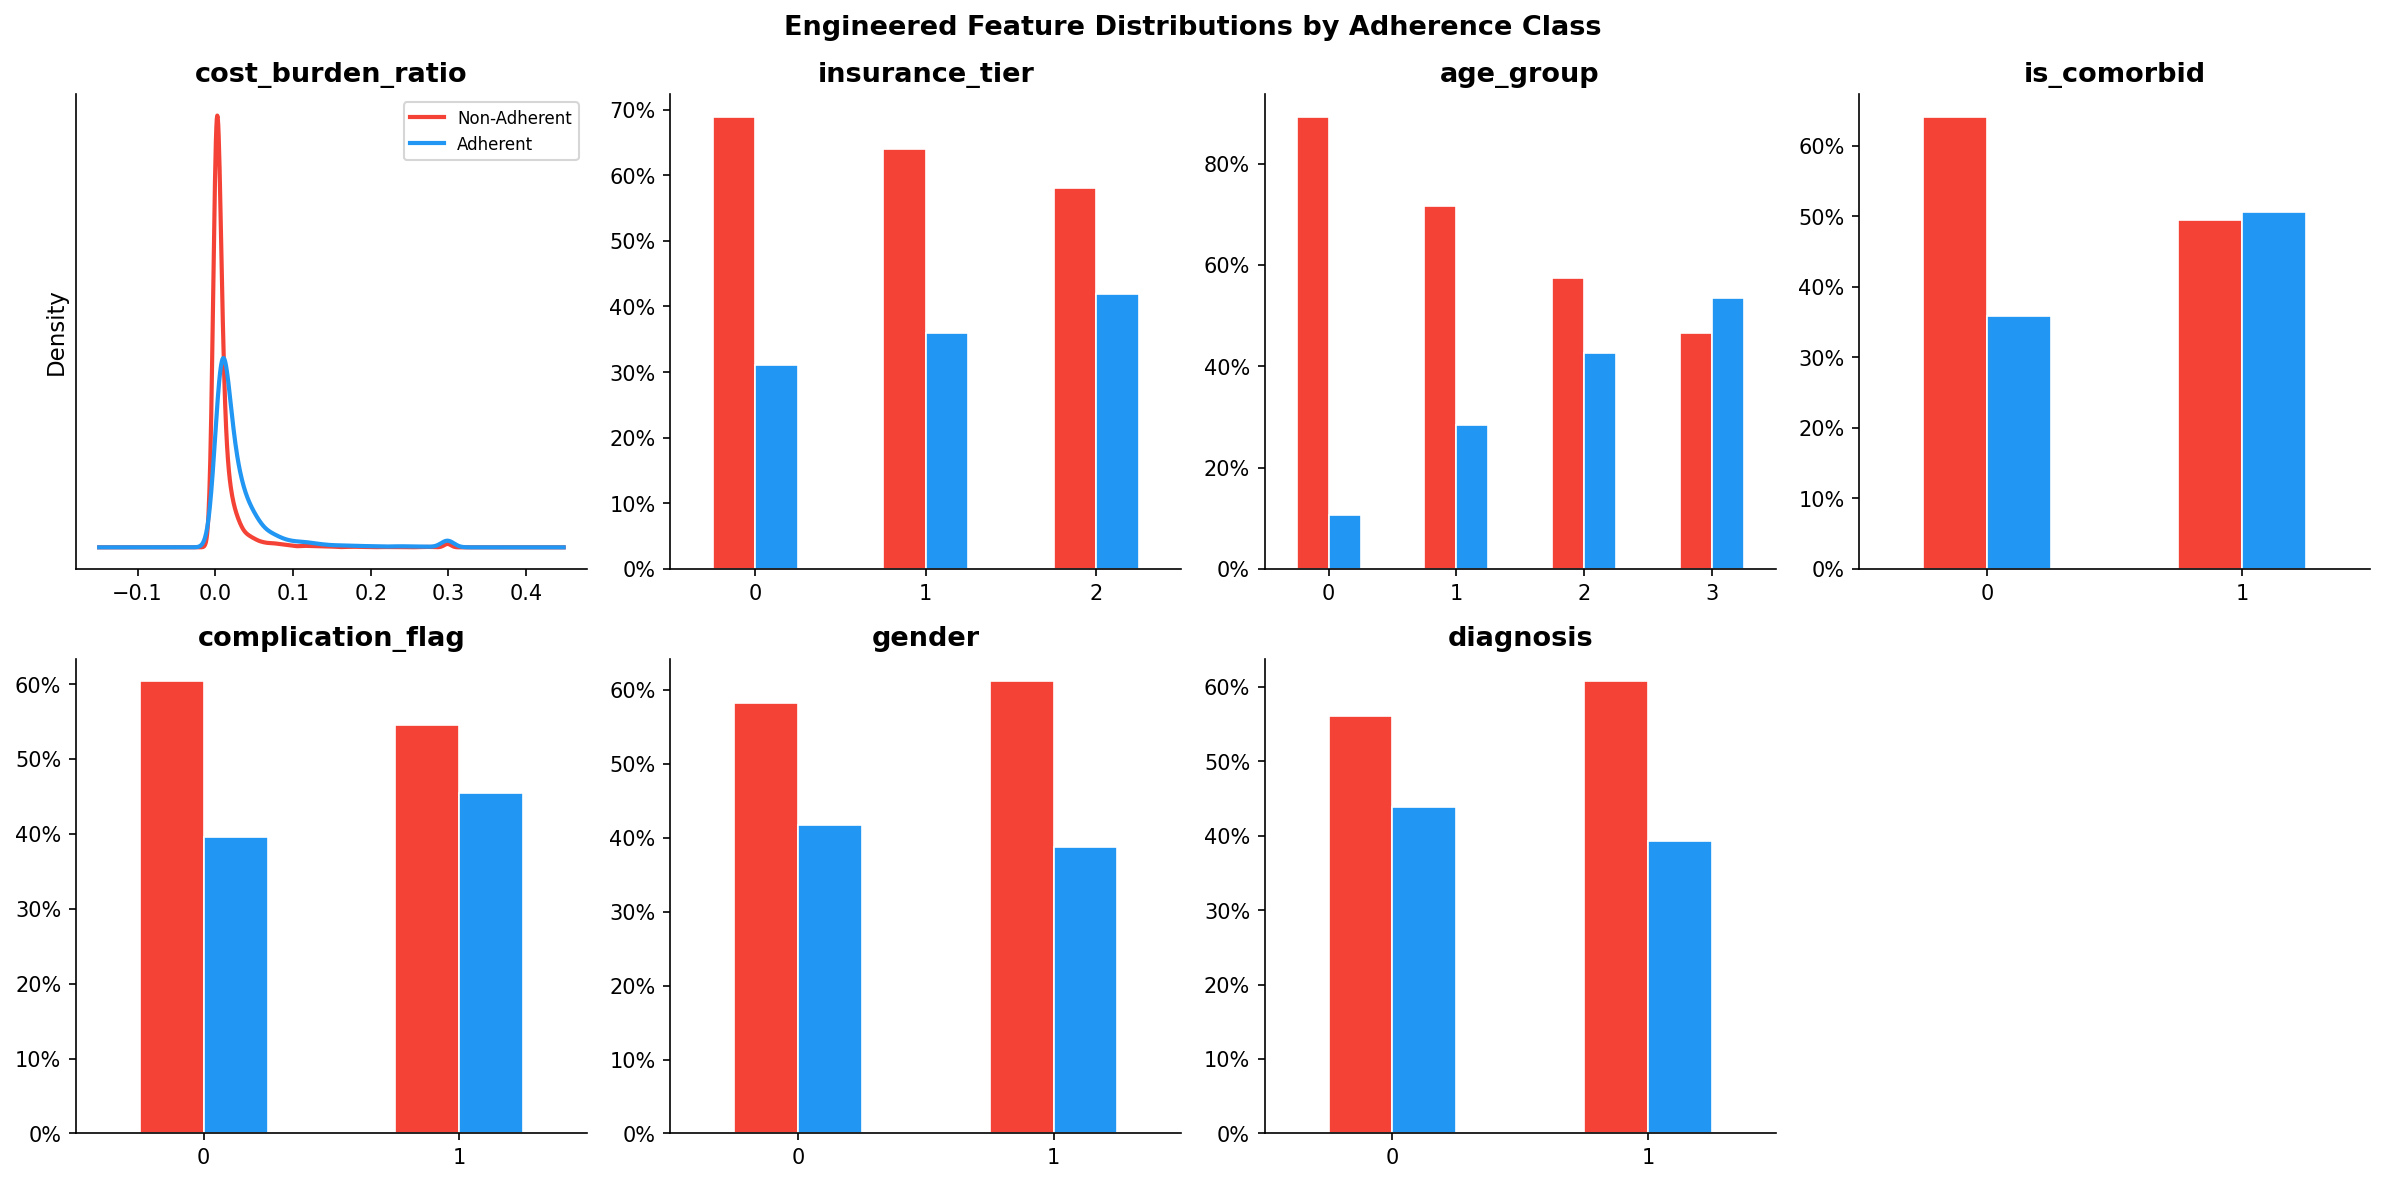

In [73]:
section("5.2 Engineered feature distributions — bar and KDE plots")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_features = [
    ("cost_burden_ratio", "KDE"),
    ("insurance_tier",    "bar"),
    ("age_group",         "bar"),
    ("is_comorbid",       "bar"),
    ("complication_flag", "bar"),
    ("gender",            "bar"),
    ("diagnosis",         "bar"),
]

for idx, (col, plot_type) in enumerate(plot_features):
    ax = axes[idx]
    if plot_type == "KDE":
        for label, grp in df.groupby(TARGET)[col]:
            colour = PALETTE["adherent"] if label == 1 else PALETTE["non_adherent"]
            name   = "Adherent" if label == 1 else "Non-Adherent"
            grp.dropna().plot.kde(ax=ax, label=name, color=colour, linewidth=2)
        ax.set_yticks([])
        ax.legend(fontsize=8)
    else:
        ct = pd.crosstab(df[col], df[TARGET], normalize="index") * 100
        ct.columns = ["Non-Adh %", "Adh %"]
        ct.plot(kind="bar", ax=ax, rot=0,
                color=[PALETTE["non_adherent"], PALETTE["adherent"]],
                edgecolor="white", linewidth=0.8, legend=(idx == 0))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xlabel("")
    ax.set_title(col, fontweight="bold")

axes[-1].set_visible(False)
fig.suptitle("Engineered Feature Distributions by Adherence Class", fontsize=13, fontweight="bold")
plt.tight_layout()

# Ensure the correct base directory for figures is used
import os
figures_base_dir = os.path.join(REPO_DIR, "figures")
figure_save_dir = os.path.join(figures_base_dir, "feature_eng")
os.makedirs(figure_save_dir, exist_ok=True)

# Save the figure using the absolute path
save_path = os.path.join(figure_save_dir, "engineered_feature_distributions.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved → {save_path}")

plt.show()

The distribution plots confirm several patterns that are consistent with the correlation results above. For `age_group`, adherence increases monotonically from the youngest cohort (18–34, adherence rate 10.7%) to the oldest (65+, adherence rate 53.5%), which is the strongest and most clinically intuitive pattern in the entire feature set. This is consistent with the literature: older patients in Sub-Saharan Africa tend to be more engaged with chronic disease management programmes and have longer-standing relationships with pharmacy staff. For `is_comorbid`, patients carrying both diabetes and hypertension show noticeably higher adherence (50.6%) than single-condition patients (35.9%), likely reflecting more intensive clinical follow-up for patients with a dual diagnosis. For `cost_burden_ratio`, the KDE distributions of the two classes overlap considerably in shape, but the adherent class is shifted rightward, meaning adherent patients tend to have higher claim amounts relative to their contributions. This makes sense directionally: a patient who is adherent collects more medication and therefore generates higher claims. The weak linear correlation (r = 0.25) captures this shift but the heavy right-skew of the distribution means a large proportion of patients cluster near zero on this feature regardless of adherence class, which limits how much a linear measure can detect.


---
## 6. Inter-Feature Correlation Heatmap

High pairwise correlation between predictors (multicollinearity) is particularly problematic for logistic regression, where it inflates coefficient standard errors and makes individual feature contributions unreliable. It is less of a concern for tree-based models, but it is still good practice to identify highly correlated feature pairs before modelling so that decisions about feature retention are made consciously rather than accidentally.



──────────────────────────────────────────────────────────────────────
  6. Inter-feature correlation; Group C
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/feature_eng/group_c_correlation_heatmap.png


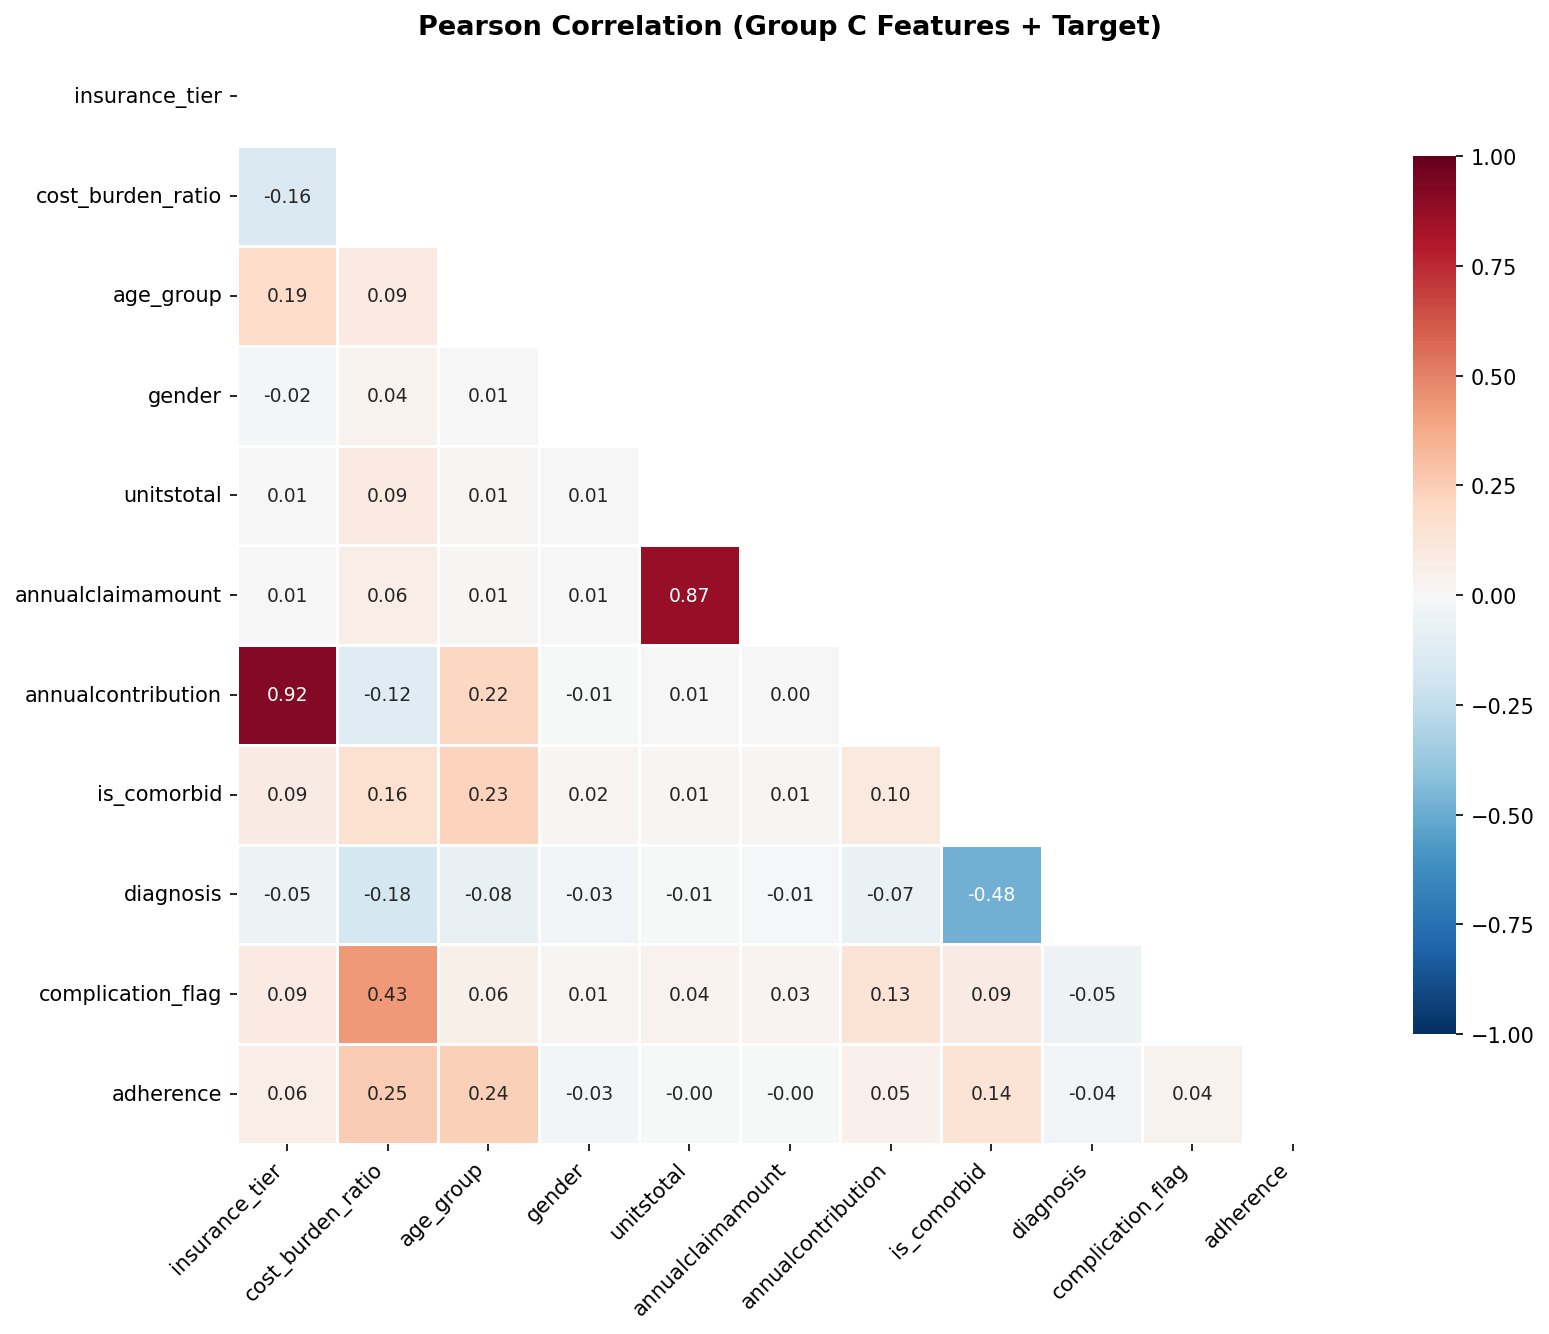


Highest absolute pairwise correlations (excluding target):
annualcontribution  insurance_tier      0.9190
annualclaimamount   unitstotal          0.8710
diagnosis           is_comorbid         0.4801
complication_flag   cost_burden_ratio   0.4323
is_comorbid         age_group           0.2315
annualcontribution  age_group           0.2160
age_group           insurance_tier      0.1919
diagnosis           cost_burden_ratio   0.1772


In [74]:
section("6. Inter-feature correlation; Group C")

corr_df = df[GROUP_C + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df, ax=ax, mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Pearson Correlation (Group C Features + Target)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_figure(fig, "group_c_correlation_heatmap.png")
plt.show()

print("\nHighest absolute pairwise correlations (excluding target):")
corr_vals = (
    corr_df.drop(columns=[TARGET]).drop(index=[TARGET])
    .abs()
    .where(np.tril(np.ones(corr_df.drop(columns=[TARGET]).drop(index=[TARGET]).shape), k=-1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(corr_vals.head(8).to_string())


The heatmap reveals two feature pairs with notably high pairwise correlations. The strongest is between `annualcontribution` and `insurance_tier` (r = 0.92), which is expected given that insurance_tier was derived directly from the scheme-type boolean columns that determine a patient's premium level. Despite this, both features are retained: `annualcontribution` carries the actual monetary premium value (a continuous signal), while `insurance_tier` captures the ordinal plan hierarchy (Basic, Medium, Premium) in a form that is more interpretable in model outputs and SHAP plots. The second highest is between `annualclaimamount` and `unitstotal` (r = 0.87), both of which measure clinical consumption volume but from different angles: `annualclaimamount` captures the monetary value of dispensed medication while `unitstotal` captures the physical quantity of units. These can diverge when unit prices differ across drug types or when a patient switches to a more expensive formulation, so both are retained.
The remaining correlations are moderate at most (r ≤ 0.48 for `diagnosis` and `is_comorbid`, which is sensible since hypertension patients are more likely to also have diabetes). There are no other pairs approaching a level that would cause serious instability in logistic regression. For that model specifically, the L2 regularisation penalty applied by default in sklearn will manage the residual multicollinearity between the two high-correlation pairs without requiring manual feature removal.

---
## 7. Stratified Train / Validation / Test Split

The dataset is split into three non-overlapping subsets: 70% training, 15% validation, and 15% test. Stratification is applied at every split to ensure that the 40/60 adherent/non-adherent ratio is preserved in each subset, which prevents the splits from accidentally concentrating non-adherent patients in training while producing an easier test set (or vice versa).

The split is performed once here and the same indices are reused across all three notebooks (03, 04, 05). This is critical for fair comparison: if each notebook split the data independently, small differences in random seeds or ordering could produce different test sets, making cross-notebook metric comparisons invalid.

The split is done in two steps: first, the combined non-test portion (85%) is separated from the test set (15%); then the non-test portion is split into training (70% of total, which is 70/85 ≈ 82.4% of the non-test portion) and validation (15% of total, which is 15/85 ≈ 17.6%).


In [75]:
section("7. Stratified 70/15/15 split")

X = df[GROUP_C].copy()
y = df[TARGET].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    random_state=SEED,
    stratify=y_temp
)

print(f"Train      : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)  "
      f"| adherent: {y_train.mean()*100:.1f}%")
print(f"Validation : {len(X_val):,} rows  ({len(X_val)/len(X)*100:.1f}%)  "
      f"| adherent: {y_val.mean()*100:.1f}%")
print(f"Test       : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.1f}%)  "
      f"| adherent: {y_test.mean()*100:.1f}%")
print(f"Total      : {len(X):,} rows")
print()
print("Stratification check: class balance is consistent across all three splits above.")



──────────────────────────────────────────────────────────────────────
  7. Stratified 70/15/15 split
──────────────────────────────────────────────────────────────────────
Train      : 16,849 rows  (70.0%)  | adherent: 40.2%
Validation : 3,611 rows  (15.0%)  | adherent: 40.2%
Test       : 3,611 rows  (15.0%)  | adherent: 40.2%
Total      : 24,071 rows

Stratification check: class balance is consistent across all three splits above.


---
## 8. Construct Per-Group Feature Matrices

Each feature group needs its own train/validation/test matrices so that the classifier in Notebooks 03 and 05 can be trained on Group A, Group B, or Group C without any code changes. The target vector (`y_train`, `y_val`, `y_test`) is the same for all three groups since the split indices are shared.

The feature matrices are subsets of the already-split `X_train`, `X_val`, and `X_test` dataframes, so no re-splitting is done here.


In [76]:
section("8. Per-group feature matrices")

X_train_A, X_val_A, X_test_A = X_train[GROUP_A], X_val[GROUP_A], X_test[GROUP_A]
X_train_B, X_val_B, X_test_B = X_train[GROUP_B], X_val[GROUP_B], X_test[GROUP_B]
X_train_C, X_val_C, X_test_C = X_train[GROUP_C], X_val[GROUP_C], X_test[GROUP_C]

for name, Xtr in [("A", X_train_A), ("B", X_train_B), ("C", X_train_C)]:
    print(f"Group {name} — train shape: {Xtr.shape}  |  features: {list(Xtr.columns)}")



──────────────────────────────────────────────────────────────────────
  8. Per-group feature matrices
──────────────────────────────────────────────────────────────────────
Group A — train shape: (16849, 4)  |  features: ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender']
Group B — train shape: (16849, 3)  |  features: ['unitstotal', 'annualclaimamount', 'annualcontribution']
Group C — train shape: (16849, 10)  |  features: ['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender', 'unitstotal', 'annualclaimamount', 'annualcontribution', 'is_comorbid', 'diagnosis', 'complication_flag']


---
## 9. Save Feature Group Pickles and Splits

Each feature group is saved as a dictionary containing the train, validation, and test arrays for that group. A separate `splits.pkl` saves the target vectors and the group column lists so that downstream notebooks can reconstruct any feature matrix from the cleaned dataframe if needed.

Pickle is used to preserve the pandas DataFrame structure (including column names and dtypes), which is important because Notebook 05's SHAP analysis relies on column names to label the feature axes.


In [77]:
section("9. Save artifacts")

def save_pkl(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved → {path}")

save_pkl(
    {"X_train": X_train_A, "X_val": X_val_A, "X_test": X_test_A,
     "y_train": y_train,   "y_val": y_val,   "y_test": y_test,
     "features": GROUP_A},
    os.path.join("/content/diabetes-hypertension-medication-adherence/data/processed/features_A.pkl")
)

save_pkl(
    {"X_train": X_train_B, "X_val": X_val_B, "X_test": X_test_B,
     "y_train": y_train,   "y_val": y_val,   "y_test": y_test,
     "features": GROUP_B},
    os.path.join("/content/diabetes-hypertension-medication-adherence/data/processed/features_B.pkl")
)

save_pkl(
    {"X_train": X_train_C, "X_val": X_val_C, "X_test": X_test_C,
     "y_train": y_train,   "y_val": y_val,   "y_test": y_test,
     "features": GROUP_C},
    os.path.join("/content/diabetes-hypertension-medication-adherence/data/processed/features_C.pkl")
)

save_pkl(
    {"y_train": y_train, "y_val": y_val, "y_test": y_test,
     "GROUP_A": GROUP_A, "GROUP_B": GROUP_B, "GROUP_C": GROUP_C,
     "train_idx": X_train.index, "val_idx": X_val.index, "test_idx": X_test.index},
    os.path.join("/content/diabetes-hypertension-medication-adherence/data/processed/splits.pkl")
)



──────────────────────────────────────────────────────────────────────
  9. Save artifacts
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/data/processed/features_A.pkl
Saved → /content/diabetes-hypertension-medication-adherence/data/processed/features_B.pkl
Saved → /content/diabetes-hypertension-medication-adherence/data/processed/features_C.pkl
Saved → /content/diabetes-hypertension-medication-adherence/data/processed/splits.pkl


In [78]:
section("9. Verification: reload and confirm shapes")

for fname, grp in [("features_A.pkl", "A"), ("features_B.pkl", "B"), ("features_C.pkl", "C")]:
    with open(os.path.join(DATA_PROC, fname), "rb") as f:
        pkg = pickle.load(f)
    print(f"Group {grp}: train={pkg['X_train'].shape}, val={pkg['X_val'].shape}, "
          f"test={pkg['X_test'].shape}, features={pkg['features']}")

print("\nNotebook 02 complete. Proceed to 03_Baseline_Models.ipynb.")



──────────────────────────────────────────────────────────────────────
  9. Verification: reload and confirm shapes
──────────────────────────────────────────────────────────────────────
Group A: train=(16849, 4), val=(3611, 4), test=(3611, 4), features=['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender']
Group B: train=(16849, 3), val=(3611, 3), test=(3611, 3), features=['unitstotal', 'annualclaimamount', 'annualcontribution']
Group C: train=(16849, 10), val=(3611, 10), test=(3611, 10), features=['insurance_tier', 'cost_burden_ratio', 'age_group', 'gender', 'unitstotal', 'annualclaimamount', 'annualcontribution', 'is_comorbid', 'diagnosis', 'complication_flag']

Notebook 02 complete. Proceed to 03_Baseline_Models.ipynb.


In [81]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    .gitignore

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/
	figures/feature_eng/

no changes added to commit (use "git add" and/or "git commit -a")


---
## 10. Push to GitHub

The four pickle files and the feature engineering figures are committed to the repository so that Notebooks 03, 04, and 05 can load them directly from the repo rather than requiring a manual Drive copy step.


In [79]:
# import shutil
# from pathlib import Path

# NB_NAME  = "02_Feature_Engineering.ipynb"
# COLAB_NB = Path(f"/content/drive/MyDrive/Colab Notebooks/{NB_NAME}")
# REPO_NB  = Path(REPO_DIR) / "notebooks" / NB_NAME
# REPO_NB.parent.mkdir(parents=True, exist_ok=True)

# if COLAB_NB.exists():
#     shutil.copy(COLAB_NB, REPO_NB)
#     print(f"Copied → {REPO_NB}")

# assert REPO_NB.exists(), f"Copy failed: {REPO_NB} not found"
# print(f"This is {REPO_DIR}")
# %cd {REPO_DIR}
# !git add .
# !git status
# !git commit -m "NB02: Feature engineering complete; group pickles saved"
# !git push
# print("Done, Notebook 02 committed and pushed.")
